In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
protein_df = pd.read_csv("ProteinAbundances.csv")
meta_df = pd.read_csv("meta_data.csv")


In [3]:
class ProteinData:
    def __init__(self, abundance_matrix, metadata):
        self.raw_data = abundance_matrix
        self.data = abundance_matrix.copy()
        self.metadata = metadata
        self.log = []
        self.decisions = {}
        self.qc_report = {}


In [4]:
def standardize_protein_index(data_df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(data_df.index, pd.RangeIndex) or data_df.index.name is None:
        first_col = data_df.columns[0]
        data_df = data_df.set_index(first_col)
        
    data_df.index.name = "uniprot_id"
    return data_df

def ingest(protein_data: pd.DataFrame, meta_data: pd.DataFrame, float32_compress = True ) -> ProteinData:
    
    #Setting Index of Proteins
    data_df = standardize_protein_index(protein_data)

    #Identifying Index of samples in MetaData
    possible_id_cols = ['Unnamed: 0', 'sample_id', 'specimenID', 'sample', 'Run', 'id']
    meta_index = next((col for col in meta_data.columns if col in possible_id_cols or 
                        any(kw in col.lower() for kw in ['id', 'sample', 'specimen'])), meta_data.columns[0])


    #Memory reduction
    if float32_compress == True:
        data_df = data_df.astype(np.float32)
    #Inner join of common samples
    data_samples = set(data_df.columns)
    meta_samples = set(meta_data[meta_index])
    common_samples = list(data_samples.intersection(meta_samples))
    print(f"[Success] Found {len(common_samples)} overlapping technical samples.")
    data_filtered = data_df[common_samples].copy()
    
    #Index recheck
    meta_filtered = meta_data[meta_data[meta_index].isin(common_samples)]
    meta_filtered = meta_filtered.set_index(meta_index)
    meta_filtered = meta_filtered.reindex(data_filtered.columns)
    if meta_filtered.index.has_duplicates:
        raise ValueError(
            "Duplicate sample IDs found in metadata."
        )
    if data_filtered.columns.has_duplicates:
        raise ValueError(
            "Duplicate sample IDs found in expression matrix."
        )
    #Replacing Zeros with NaNs
    data_filtered = data_filtered.replace(0.0, np.nan)
    meta_filtered = meta_filtered.replace(0.0, np.nan)
    
    
    return ProteinData(data_filtered, meta_filtered)

In [5]:

from time import perf_counter
start = perf_counter()
protdata = ingest(protein_df, meta_df)
end = perf_counter()
print(end - start)

[Success] Found 558 overlapping technical samples.
0.21692689997144043


# Missingness Analysis

In [6]:
from dataclasses import dataclass
@dataclass
class MissingnessReport:
    per_protein_missingness: pd.Series
    per_sample_missingness: pd.Series
    overall_missingness: float
    batch_missingness: pd.Series

    spearman_r: float
    spearman_pval: float
    mechanism: str
    imputation_recommendation: list[str]
    

In [7]:
def missingness_nature(data_df: pd.DataFrame,  pval_threshold = 0.05, corr_threshold = 0.3, ):
    
    log2_df = np.log2(data_df.replace(0.0, np.nan))

    detection_rate = log2_df.notna().mean(axis = 1)
    mean_intensity_detected = log2_df.mean(axis=1, skipna=True)

    mask = detection_rate > 0
    detection_rate = detection_rate[mask]
    mean_intensity_detected = mean_intensity_detected[mask]
    from scipy.stats import spearmanr
    corr, pval = spearmanr(detection_rate, mean_intensity_detected)
    spearman_r = corr
    spearman_pval = pval
    if corr > corr_threshold and pval < pval_threshold:
        mechanism = "MNAR"
        imputation_recommendation = ["minimum_value", "KNN_within_batch"]
    elif abs(corr) < 0.1:
        mechanism = "MCAR"
        imputation_recommendation = ["mean", "KNN", "iterative"]
    else:
        mechanism = "MAR"
        imputation_recommendation = ["MissForest", "iterative"]

    return spearman_r, spearman_pval, mechanism, imputation_recommendation 
    


In [8]:
def compute_missingness(data_df, meta_df, pval_threshold = 0.05, corr_threshold = 0.03, ):
    batch_missingness = {}
    report = {}
    
    per_protein_missingness = pd.Series(data_df.isna().mean(axis=1) * 100)
    per_sample_missingness = pd.Series(data_df.isna().mean(axis = 0) * 100)
    overall_missingness = data_df.isna().mean().mean() * 100

    
    possible_batch_cols = ["Batch_overall","batch","Batch","Batches","MS_Batch","RunBatch"]
 
    batch_col = next(
        (c for c in meta_df.columns
         if c in possible_batch_cols or "batch" in c.lower()),
        None
    )
    sample_to_batch = meta_df[batch_col].dropna()
    common = data_df.columns.intersection(sample_to_batch.index)
    expr_aligned = data_df[common]

    batch_missingness = (
        expr_aligned
        .isna()
        .T
        .groupby(sample_to_batch[common].values)
        .mean()
        .mean(axis=1) * 100
    ).sort_values(ascending = False)
        
    batch_missingness = pd.Series(batch_missingness).sort_values(ascending = False)
    spearman_r, spearman_pval, mechanism, imputation_recommendation = missingness_nature(data_df, pval_threshold = pval_threshold, corr_threshold = corr_threshold)
    report = MissingnessReport(per_protein_missingness, per_sample_missingness, overall_missingness, batch_missingness, spearman_r, spearman_pval, mechanism, imputation_recommendation)
    return report

    


In [9]:
from time import perf_counter
start = perf_counter()
report = compute_missingness(protdata.data, protdata.metadata)
end = perf_counter()
print(end - start)

0.29179139994084835


In [10]:
print(report.per_protein_missingness.mean())
print(report.per_sample_missingness.mean())
print(report.overall_missingness)

22.33700568477125
22.33700568477125
22.33700568477125


In [11]:
report.per_protein_missingness.describe()


count    11958.000000
mean        22.337006
std         33.609105
min          0.000000
25%          0.000000
50%          0.000000
75%         40.501792
max        100.000000
dtype: float64

In [12]:
report.per_sample_missingness.describe()


count    558.000000
mean      22.337006
std        4.251712
min       13.329988
25%       19.902994
50%       23.189497
75%       24.201371
max       33.575849
dtype: float64

In [19]:
meta_df.columns

Index(['Unnamed: 0', 'Batch_overall', 'Original.Order',
       'ROSMAP.MulticonsensusStudyFileID', 'TMTquantMS2or3', 'projid.ROSMAP',
       'study.ROSMAP', 'scaled_to.ROSMAP', 'apoe_genotype', 'ApoE4.Dose',
       'ApoE.Risk', 'age_first_ad_dx', 'cogdx', 'cogdx_stroke', 'dxpark',
       'cogn_global_lv', 'cts_mmse30_lv', 'age_death', 'educ', 'msex', 'race7',
       'braaksc', 'ceradsc_RADCnonStd', 'gpath', 'niareagansc', 'pmi',
       'amyloid', 'amyloid_mf', 'dlbdx', 'mglia123_mf', 'mglia23_mf',
       'mglia3_mf', 'nft', 'tangles', 'tangles_mf', 'tdp_cs_6reg', 'tdp_st4',
       'brainwt', 'CERAD', 'JohnsonDiagnosis', 'CaseID.Banner',
       'LFQ.ID.Banner', 'PlaqueTotal.Banner', 'SNCA.P37840', 'TARDBP.Q13148',
       'Abeta.6.28..2.peptide..MS.Relative.Quantification',
       'MAPT.Microtubule.Binding.Repeats..MTBR..Region.MS.Relative.Quantification',
       'MAPT.deltaMTBR..3.isoforms.with.MTBR.removed.from.sequence..Summed.Signal',
       'MTBR.deltaMTBR.Ratio', 'Cohort', 'Outlier

## Batch Metrics Evaluation Functions

In [20]:
def anova_batch_vectorized(data_df, meta_df, batch_col, alpha = 0.05):
    from scipy.stats import f as f_dist
    
    expr = data_df.values.astype(float)  # proteins x samples
    batch = meta_df[batch_col].values
    unique_batches = np.unique(batch[~pd.isna(batch)])
    
    n_proteins, n_samples = expr.shape
    grand_mean = np.nanmean(expr, axis=1, keepdims=True)  # proteins x 1
    
    k = len(unique_batches)
    n = np.sum(~np.isnan(expr), axis=1)  # per protein sample count
    
    # Between-group sum of squares
    ss_between = np.zeros(n_proteins)
    ss_within = np.zeros(n_proteins)
    
    for b in unique_batches:
        mask = batch == b
        group = expr[:, mask]
        group_mean = np.nanmean(group, axis=1)
        group_n = np.sum(~np.isnan(group), axis=1)
        ss_between += group_n * (group_mean - grand_mean.squeeze()) ** 2
        ss_within += np.nansum((group - group_mean[:, None]) ** 2, axis=1)
    
    df_between = k - 1
    df_within = n - k
    
    ms_between = ss_between / df_between
    ms_within = ss_within / df_within
    
    f_stat = ms_between / ms_within
    p_values = f_dist.sf(f_stat, df_between, df_within)
    print("ANOVA test successfully executed and returned.")
    anova_df =  pd.DataFrame({
        "protein": data_df.index,
        "F": f_stat,
        "p_value": p_values,
        "significant": p_values < (alpha / n_proteins) 
    }).set_index("protein")
    anova_sorted = anova_df.sort_values(by = "F", ascending= False)
    anova_sorted["Flag"] = ((anova_sorted["F"] > anova_sorted["F"].mean()) & (anova_sorted["p_value"] < 0.05))
    return anova_sorted
    

In [21]:
from scipy.stats import kruskal

def kruskal_batch(data_df: pd.DataFrame, meta_df: pd.DataFrame, batch_col: str, alpha: float = 0.05,):
    print("Running Kruskal Wallis test per protein...")
    batch = meta_df.loc[data_df.columns, batch_col].to_numpy()
    unique_batches = np.unique(batch[~pd.isna(batch)])

    H = np.empty(len(data_df), dtype=float)
    P = np.empty(len(data_df), dtype=float)

    values = data_df.to_numpy(dtype=float)

    
    batch_masks = [batch == b for b in unique_batches]
    print("Looping over proteins..")
    for i in range(values.shape[0]):
        protein = values[i]

        groups = []

        for mask in batch_masks:
            g = protein[mask]
            g = g[~np.isnan(g)]

            if len(g):
                groups.append(g)

        if len(groups) < 2:
            H[i] = np.nan
            P[i] = np.nan
            continue

        try:
            H[i], P[i] = kruskal(*groups)
        except ValueError:
            H[i] = np.nan
            P[i] = np.nan

    result = pd.DataFrame(
        {
            "H": H,
            "p_value": P,
        },
        index=data_df.index,
    )

    bonf = alpha / len(result)

    result["significant"] = result["p_value"] < bonf

    result["flag"] = result["significant"]
    print("Kruskal Wallis test successfully executed and returned.")
    return result

In [22]:
@dataclass
class BatchMetrics:
    batch_effect_per_protein: pd.DataFrame
    batch_effect_flag: bool
    silhoutte_score: np.float32
    chi_square_metric: np.float32
    r_sq_median: np.float32
    r_sq_mean: np.float32
    r_sq_dist: np.float32
    

In [23]:
def batch_variation_test(protdata: ProteinData, batch_effect_method: str = "anova", alpha: float = 0.05):
    
    possible_batch_cols = ["Batch_overall","batch","Batch","Batches","MS_Batch","RunBatch"]
 
    batch_col = next(
        (c for c in protdata.metadata.columns
         if c in possible_batch_cols or "batch" in c.lower()),
        None
    )
    #Performing Batch Effect Flagging
    if batch_effect_method == "anova":
        batch_effect_per_protein = anova_batch_vectorized(data_df=protdata.data, meta_df=protdata.metadata, batch_col  = batch_col, alpha = alpha)
    elif batch_effect_method == "kruskal_wallis":
        batch_effect_per_protein = kruskal_batch(data_df=protdata.data, meta_df=protdata.metadata, batch_col  = batch_col, alpha = alpha )
        #n_proteins = batch_effect_per_protein[batch_effect_per_protein["Flag"] == True].sum()
        #n_proteins_pct = n_proteins/len(batch_effect_per_protein)
    else:
        print("Please choose appropriate batch effect method. [anova, kruskal_wallis]")
        return None
    return batch_effect_per_protein

## Variance Functions

In [24]:
def variance_explained(data_df: pd.DataFrame, meta_df: pd.DataFrame, factor: str,):
    expr = data_df.to_numpy(dtype = float)
    factors = meta_df.loc[data_df.columns, factor].to_numpy()
    unique_groups = np.unique(factors[~pd.isna(factors)])
    n_proteins, n_samples = expr.shape

    grand_mean = np.nanmean(expr, axis = 1, keepdims=True)
    ss_between = np.zeros(n_proteins)
    ss_within = np.zeros(n_proteins)

    for g in unique_groups:
        mask = factors == g
        group = expr[:, mask]
        group_mean = np.nanmean(group, axis = 1)
        group_n = np.sum(~np.isnan(group), axis = 1)
        ss_between += group_n * (group_mean - grand_mean.squeeze())**2
        ss_within += np.nansum((group - group_mean[:, None]) ** 2, axis=1)

    r2 = ss_between/(ss_between + ss_within)
    
    variance_per_protein = pd.Series(r2, index = data_df.index, name = factor )
    summary = {
        "factor": factor,
        "mean_r2": np.nanmean(r2),
        "median_r2": np.nanmedian(r2),
        "std_r2": np.nanstd(r2),
        "q25": np.nanpercentile(r2, 25),
        "q75": np.nanpercentile(r2, 75),
        "min_r2": np.nanmin(r2),
        "max_r2": np.nanmax(r2),
    }
    return variance_per_protein, summary


In [25]:

expr = protdata.data.to_numpy(dtype = float)
factor = protdata.metadata.loc[protdata.data.columns, "Batch_overall"].to_numpy()

import statsmodels.api as sm
from statsmodels.formula.api import ols

anova_df = pd.DataFrame({
    "expr": expr[0],
    "batch": factor
}).dropna()

model = ols("expr ~ C(batch)", data=anova_df).fit()

print(model.rsquared)

0.9833580272515817


In [26]:
from time import perf_counter
start = perf_counter()
variance, summary = variance_explained(data_df=protdata.data, meta_df=protdata.metadata, factor= "Batch_overall")
end = perf_counter()
print(end - start)
print(variance.sort_values(ascending = False))
print("\n", summary)

0.20594780007377267
uniprot_id
ATPAF2|Q8N5M1     0.991567
TOMM22|Q9NS69     0.990123
PRKAA1|Q13131     0.989917
KIF2C|Q99661      0.989710
CWF19L1|Q69YN2    0.989669
                    ...   
ZSCAN26|Q16670         NaN
ZUP1|Q96AP4            NaN
ZWILCH|Q9H900          NaN
ZXDC|Q2QGD7            NaN
ZZZ3|Q8IYH5            NaN
Name: Batch_overall, Length: 11958, dtype: float64

 {'factor': 'Batch_overall', 'mean_r2': np.float64(0.9652988923699567), 'median_r2': np.float64(0.9769772397114663), 'std_r2': np.float64(0.0496328317023611), 'q25': np.float64(0.9688939983218066), 'q75': np.float64(0.9812500468689034), 'min_r2': np.float64(0.1601681084773577), 'max_r2': np.float64(0.9915666343626633)}


C:\Users\Khalid Mohammad\AppData\Local\Temp\ipykernel_36996\1927094561.py:7: RuntimeWarning: Mean of empty slice
  grand_mean = np.nanmean(expr, axis = 1, keepdims=True)
C:\Users\Khalid Mohammad\AppData\Local\Temp\ipykernel_36996\1927094561.py:14: RuntimeWarning: Mean of empty slice
  group_mean = np.nanmean(group, axis = 1)


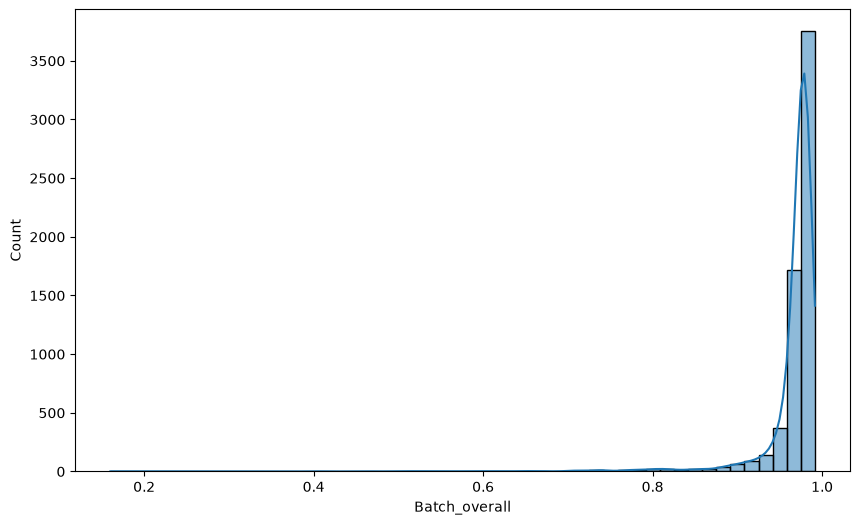

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(variance, kde = True, bins = 50)
plt.show()

In [28]:
def compare_explained_variances(data_df, meta_df, factors: list[str]):
    summaries = []
    per_protein_frames = []

    for factor in factors:
        valid_samples = meta_df[factor].dropna().index
        valid_samples = valid_samples.intersection(data_df.columns)

        r2_series, summary = variance_explained(data_df = protdata.data, meta_df=protdata.metadata, factor = factor)

        summaries.append(summary)
        per_protein_frames.append(r2_series)
    comparison_df = pd.concat(per_protein_frames, axis = 1)
    summary_df = pd.DataFrame(summaries).set_index("factor")

    return comparison_df, summary_df

In [29]:
from time import perf_counter
start = perf_counter()
comp_df, sum_df = compare_explained_variances(data_df=protdata.data, meta_df=protdata.metadata, factors= ["Batch_overall", "JohnsonDiagnosis", "cogdx", "braaksc", "niareagansc", "msex"])
end = perf_counter()
print(end - start)



C:\Users\Khalid Mohammad\AppData\Local\Temp\ipykernel_36996\1927094561.py:7: RuntimeWarning: Mean of empty slice
  grand_mean = np.nanmean(expr, axis = 1, keepdims=True)
C:\Users\Khalid Mohammad\AppData\Local\Temp\ipykernel_36996\1927094561.py:14: RuntimeWarning: Mean of empty slice
  group_mean = np.nanmean(group, axis = 1)


1.357716100057587


In [30]:
comp_df.head(10)

,Batch_overall,JohnsonDiagnosis,cogdx,braaksc,niareagansc,msex
uniprot_id,,,,,,
|A6NIZ1,0.983358,0.038387,0.979518,0.083691,0.979549,0.075610
|A6NNZ2,0.982788,0.030591,0.940555,0.063946,0.942056,0.070171
|B2RBV5,NaN,0.064289,NaN,NaN,0.183040,0.120300
|P00761,0.975779,0.042780,0.950320,0.085752,0.951167,0.067957
|P02441,NaN,0.076206,NaN,NaN,NaN,0.929225
|P02534,0.231122,0.006730,0.015122,0.005883,0.001698,0.026083
|P02539,NaN,0.083488,NaN,0.086888,NaN,0.993318
|P0DPK5,NaN,0.069360,0.912728,0.062068,0.913255,0.027927
|P15241,0.771235,0.108394,0.847153,0.145816,0.853588,0.041571


In [31]:
sum_df.head(10)

,mean_r2,median_r2,std_r2,q25,q75,min_r2,max_r2
factor,,,,,,,
Batch_overall,0.965299,0.976977,0.049633,0.968894,0.981250,1.601681e-01,0.991567
JohnsonDiagnosis,0.029597,0.020999,0.051884,0.013398,0.028177,8.796107e-05,0.997123
cogdx,0.543151,0.617104,0.291181,0.298036,0.785724,9.889110e-04,0.999969
braaksc,0.048627,0.045848,0.034629,0.031312,0.057646,1.150154e-03,0.951577
niareagansc,0.525096,0.594263,0.303477,0.239160,0.784612,3.666993e-04,0.999987
msex,0.045116,0.035388,0.088810,0.018952,0.047620,2.382203e-09,1.000000


## Silhoutte Score

In [32]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X = protdata.data.copy().T
X = X.fillna(0)
meta = protdata.metadata.copy()
meta = meta.loc[X.index]
pca = PCA(n_components= 2)
X_pca = pca.fit_transform(X)
batch_labels = meta["Batch_overall"]

score = silhouette_score(X_pca, labels = batch_labels)
print(score)

-0.1873084455728531


In [33]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
def sh_score(data_df, meta_df, batch_labels):
    X = data_df.copy().T.fillna(0)
    meta = meta_df.copy()
    meta = meta.loc[X.index]
    pca = PCA()
    X_pca = pca.fit_transform(X)
    labels = meta[batch_labels]

    score = silhouette_score(X_pca, labels= labels)
    return score, X_pca

In [34]:
score, x_pca = sh_score(protdata.data, protdata.metadata, batch_labels="Batch_overall")
score

0.010054590180516243

In [35]:
x_pca[:,2]

array([ 2.27187968e+09, -1.70008944e+08,  1.82365389e+09, -7.09686960e+07,
       -9.84887552e+08,  2.31527632e+08,  9.08797696e+08, -2.33280410e+09,
       -1.91230016e+09, -2.84544666e+09,  3.25059872e+08, -9.74109568e+08,
        2.07580752e+08,  5.15789024e+08, -1.83881152e+08,  8.30321408e+08,
        2.21247328e+08,  2.00870851e+10,  1.97134656e+08, -2.62106726e+09,
       -1.66025370e+09,  4.10934246e+09,  3.05618918e+09,  8.61999040e+07,
        1.97931808e+08,  2.93150016e+08,  4.72383296e+08,  6.82656512e+08,
        2.59060320e+08,  5.55154760e+07, -2.65443740e+07,  6.64502464e+08,
        1.63669280e+08,  1.01372680e+08,  3.27388160e+08,  1.83475328e+09,
       -4.58906272e+08, -2.84527155e+09, -5.87773056e+08,  3.33278336e+08,
        3.48827584e+08, -7.16095040e+08,  1.05848192e+09, -4.72380723e+09,
       -1.79812224e+09, -2.73021158e+09,  1.22317976e+08,  4.86796416e+08,
       -1.32486672e+08,  1.20072384e+09, -3.85824672e+08,  3.16572979e+09,
       -1.41751235e+10,  

## Filtering low detection proteins and samples

In [36]:
from omicsqc.ingestion import ingest_data
from omicsqc.qc_layer.qc_metrics import compute_qc_pipeline
protdata = ingest_data(protein_data= protein_df, meta_data= meta_df,)
protdata = compute_qc_pipeline(protdata= protdata, protein_threshold_pct= 40, 
                               variation_factors= ["Batch_overall", "JohnsonDiagnosis", "cogdx", "braaksc", "niareagansc", "msex"])


[Success] Found 558 overlapping technical samples.


TypeError: compute_qc_pipeline() missing 2 required positional arguments: 'data_df' and 'meta_df'

In [ ]:
protdata.missingness_report.missingness_inference

'Evidence of intensity-dependent missingness, consistent with left-censoring  '

In [ ]:
from omicsqc.models import ProteinData
def filter_data(protdata: ProteinData, protein_missingness_threshold_pct: np.float16, sample_missingness_threshold_pct: np.float16):
    missingness = protdata.missingness_report
    valid_proteins = missingness.per_protein_missingness[missingness.per_protein_missingness <= protein_missingness_threshold_pct].index
    valid_samples = missingness.per_sample_missingness[missingness.per_sample_missingness <= sample_missingness_threshold_pct].index
    protdata.filtered_data = protdata.data.loc[valid_proteins, valid_samples]
    protdata.filtered_metadata = protdata.metadata.loc[valid_samples]
    return protdata

In [ ]:
protdata = filter_data(protdata, 40, 60)

In [ ]:
protdata.missingness_report.per_protein_missingness

uniprot_id
|A6NIZ1           0.000000
|A6NNZ2           0.000000
|B2RBV5          92.652330
|P00761           0.000000
|P02441          95.519713
                   ...    
ZXDC|Q2QGD7      96.953405
ZYG11B|Q9C0D3     0.000000
ZYX|Q15942        0.000000
ZZEF1|O43149      0.000000
ZZZ3|Q8IYH5      79.032258
Length: 11958, dtype: float64

In [ ]:
result = filter_data(protdata, 40, 40)
print(result)
print(type(result))

ProteinData()
<class 'omicsqc.models.ProteinData'>


In [ ]:
protdata.filtered_data

AttributeError: 'NoneType' object has no attribute 'head'

## Applying log transformation + median-centering normalization

In [38]:
def median_centering(protdata: ProteinData):
    log2_expr = np.log2(protdata.filtered_data)
    
    sample_medians = log2_expr.median(axis=0)  # per-sample median, shape (n_samples,)
    normalized = log2_expr - sample_medians     # broadcasts correctly
    
    protdata.transformed_data = normalized
    protdata.data = normalized.copy()
    protdata.logs.append("Log2 transform and median normalization applied")
    return protdata


In [39]:
protdata = median_centering(protdata)

TypeError: loop of ufunc does not support argument 0 of type NoneType which has no callable log2 method

In [40]:
protdata.transformed_data.describe()

AttributeError: 'NoneType' object has no attribute 'describe'

In [41]:
protdata.filtered_data.describe()

AttributeError: 'NoneType' object has no attribute 'describe'

# Applying Imputation Algorithms

In [42]:
protdata.missingness_report.missingness_inference

AttributeError: 'NoneType' object has no attribute 'missingness_inference'

## MinProb Imputation technique

In [44]:
def MinProbImpute(data_df: pd.DataFrame, lmbda: np.float16, sigma: np.float16):
    og_matrix = data_df.to_numpy()
    mu = np.nanmean(og_matrix, axis = 0, keepdims=True)
    sigma = np.nanstd(og_matrix, axis = 0, ddof=1)
    lmbda = 1.8
    mu_imp = mu - (lmbda * sigma)
    d = 0.3
    sigma_imp = d * sigma
    imputed = og_matrix.copy()
    mask = np.isnan(og_matrix)
    random_matrix = np.random.normal(loc = mu_imp, scale = sigma_imp, size= imputed.shape)
    imputed[mask] = random_matrix[mask]
    return pd.DataFrame(imputed, columns= data_df.columns, index=data_df.index)

In [45]:
data = protdata.transformed_data.copy()
imputed = MinProbImpute(data_df= data, lmbda = 1.8, sigma= 0.3)
imputed_df = pd.DataFrame(imputed, columns= data.columns, index=data.index)

In [47]:
from omicsqc.qc_layer.qc_metrics import compute_qc_individual
tempreport = compute_qc_individual(imputed_df, protdata.metadata, 40, 
                                   variation_factors= ["Batch_overall", "JohnsonDiagnosis", "cogdx", "braaksc", "niareagansc", "msex"])

In [48]:
tempreport.logs

['missingness analysis not applicable because no missing values remain',
 '[Batch Variation Test]\n    Statistical method:             anova \n\n    Significance level (alpha):     0.05 \n\n    Protein threshold:              40.00% \n\n    Significant proteins:           8947 \n\n    Significant proteins (%):       100.00% \n\n    Batch effect detected:          True \n\n    silhoutte score:                0.6291',
 '[Explained Variance Comparison]\n    Factors analyzed:               Batch_overall, JohnsonDiagnosis, cogdx, braaksc, niareagansc, msex\n    Per-protein comparison shape:   (8947, 6)\n    Summary dataframe shape:        (6, 7)']

In [49]:
temp_report_preimpute = compute_qc_individual(protdata.data, protdata.metadata, 40,
                                             variation_factors=["Batch_overall", "JohnsonDiagnosis", "cogdx", "braaksc", "niareagansc", "msex"])
temp_report_preimpute.logs

c:\Users\Khalid Mohammad\Projects\omicsqc\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


['[Missingness Analysis]\n        Per-protein missingness (mean): 4.11%\n        Per-sample missingness (mean):  4.11%\n        Overall missingness:            4.11%\n        Spearman coefficient:           0.8909\n        Spearman p-value:               0.0000e+00\n        Inferred missingness nature: Evidence of intensity-dependent missingness, consistent with left-censoring',
 '[Batch Variation Test]\n    Statistical method:             anova \n\n    Significance level (alpha):     0.05 \n\n    Protein threshold:              40.00% \n\n    Significant proteins:           8947 \n\n    Significant proteins (%):       100.00% \n\n    Batch effect detected:          True \n\n    silhoutte score:                0.8115',
 '[Explained Variance Comparison]\n    Factors analyzed:               Batch_overall, JohnsonDiagnosis, cogdx, braaksc, niareagansc, msex\n    Per-protein comparison shape:   (8947, 6)\n    Summary dataframe shape:        (6, 7)']

In [50]:
protdata = ingest(protein_df, meta_df)
protdata = compute_qc_pipeline(protdata, protein_threshold_pct=40, variation_factors=["Batch_overall", "JohnsonDiagnosis", "cogdx", "braaksc", "niareagansc", "msex"])
protdata.logs

[Success] Found 558 overlapping technical samples.


['[Missingness Analysis]\n        Per-protein missingness (mean): 22.34%\n        Per-sample missingness (mean):  22.34%\n        Overall missingness:            22.34%\n        Spearman coefficient:           0.8788\n        Spearman p-value:               0.0000e+00\n        Inferred missingness nature: Evidence of intensity-dependent missingness, consistent with left-censoring',
 '[Batch Variation Test]\n    Statistical method:             anova \n\n    Significance level (alpha):     0.05 \n\n    Protein threshold:              40.00% \n\n    Significant proteins:           10586 \n\n    Significant proteins (%):       88.53% \n\n    Batch effect detected:          True \n\n    silhoutte score:                0.0101',
 '[Explained Variance Comparison]\n    Factors analyzed:               Batch_overall, JohnsonDiagnosis, cogdx, braaksc, niareagansc, msex\n    Per-protein comparison shape:   (11958, 6)\n    Summary dataframe shape:        (6, 7)']

In [52]:
from omicsqc.preprocessing.transform import transform_data

protdata = transform_data(protdata, 40, 60)
imputed = MinProbImpute(protdata.transformed_data, 1.8, 0.3)
temp_report = compute_qc_individual(imputed, protdata.filtered_metadata, 40, variation_factors = ["Batch_overall", "JohnsonDiagnosis", "cogdx", "braaksc", "niareagansc", "msex"])
temp_report.logs

['missingness analysis not applicable because no missing values remain',
 '[Batch Variation Test]\n    Statistical method:             anova \n\n    Significance level (alpha):     0.05 \n\n    Protein threshold:              40.00% \n\n    Significant proteins:           8947 \n\n    Significant proteins (%):       100.00% \n\n    Batch effect detected:          True \n\n    silhoutte score:                0.6291',
 '[Explained Variance Comparison]\n    Factors analyzed:               Batch_overall, JohnsonDiagnosis, cogdx, braaksc, niareagansc, msex\n    Per-protein comparison shape:   (8947, 6)\n    Summary dataframe shape:        (6, 7)']

In [ ]:
missingness = compute_missingness(imputed, protdata.filtered_metadata)

c:\Users\Khalid Mohammad\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


0.0

## Batch Correction Function

In [ ]:
from inmoose.pycombat import pycombat_norm
import numpy as np
import pandas as pd

def run_combat(imputed_df: pd.DataFrame, meta_df: pd.DataFrame, batch_col: str,
               covariates: list[str] | None = None):
    batch = meta_df.loc[imputed_df.columns, batch_col]

    covar_df = None
    if covariates:
        covar_df = meta_df.loc[imputed_df.columns, covariates]

    corrected = pycombat_norm(
        imputed_df,
        batch,
        covar_mod=covar_df,
    )
    return corrected

ModuleNotFoundError: No module named 'inmoose'